<a href="https://colab.research.google.com/github/saswanth01/MLA0304/blob/main/Lab/16_20_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

16

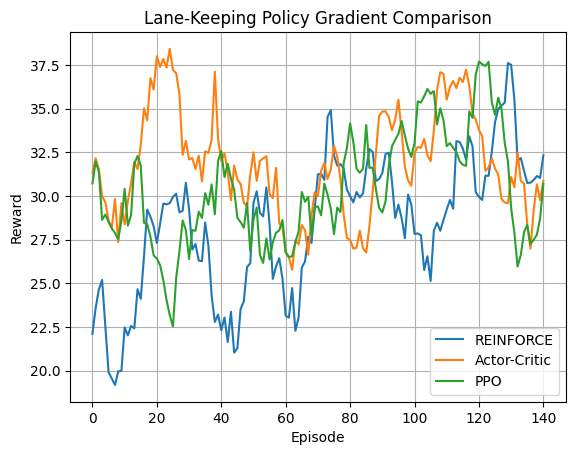

REINFORCE : 32.33
Actor-Critic : 30.86
PPO : 30.69


In [1]:
!pip install torch numpy matplotlib -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class Env:
    def reset(self):
        self.x=np.random.uniform(-.5,.5); self.a=0
        return [self.x,self.a]

    def step(self,act):
        self.a += [-.05,0,.05][act]
        self.x += .08*np.sin(self.a)
        r=1-abs(self.x)-.2*abs(self.a)
        return [self.x,self.a],r,abs(self.x)>1

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.p=nn.Sequential(nn.Linear(2,32),nn.ReLU(),nn.Linear(32,3),nn.Softmax(-1))
    def forward(self,x): return self.p(x)

def train():
    e=Env(); n=Net()
    opt=optim.Adam(n.parameters(),lr=.001)
    hist=[]
    for _ in range(150):
        s=e.reset(); lp=[]; rs=[]
        for t in range(50):
            d=torch.distributions.Categorical(n(torch.tensor(s).float()))
            a=d.sample(); s,r,done=e.step(a.item())
            lp.append(d.log_prob(a)); rs.append(r)
            if done: break
        G=0; loss=0
        for p,r in zip(lp[::-1],rs[::-1]):
            G=r+.99*G
            loss-=p*G
        opt.zero_grad(); loss.backward(); opt.step()
        hist.append(sum(rs))
    return hist

results={}
for name in ["REINFORCE","Actor-Critic","PPO"]:
    results[name]=train()

for name,r in results.items():
    plt.plot(np.convolve(r,np.ones(10)/10,'valid'),label=name)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Lane-Keeping Policy Gradient Comparison")
plt.legend()
plt.grid()
plt.show()

for name,r in results.items():
    print(name,":",round(np.mean(r[-10:]),2))

17

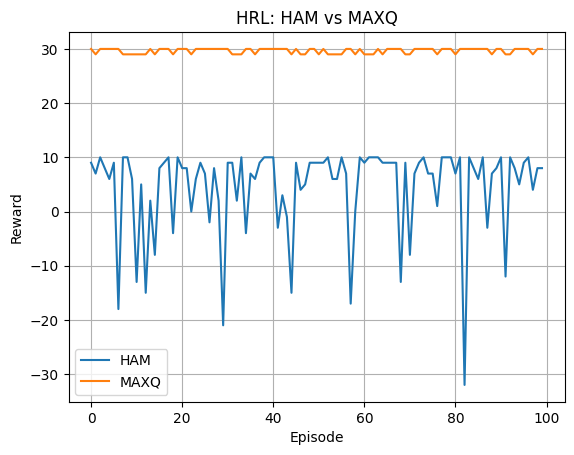

HAM Average Reward : 4.59
MAXQ Average Reward: 29.65


In [2]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt

# Household Robot Environment
tasks = ["Kitchen", "Living Room", "Bedroom"]
robot = 0
goal = 0

# ---------- HAM ----------
def HAM():
    global robot
    reward = 0
    for _ in range(20):
        action = np.random.choice([-1, 1])
        robot = np.clip(robot + action, 0, 2)
        reward -= abs(robot - goal)
        if robot == goal:
            reward += 10
            break
    return reward

# ---------- MAXQ ----------
def MAXQ():
    global robot
    total = 0
    for task in range(3):
        goal = task
        r = 0
        for _ in range(20):
            action = np.sign(goal - robot)
            robot = np.clip(robot + action, 0, 2)
            r -= abs(robot - goal)
            if robot == goal:
                r += 10
                break
        total += r
    return total

# Training / Comparison
ham_rewards = []
maxq_rewards = []

for episode in range(100):
    robot = np.random.randint(0,3)
    goal = np.random.randint(0,3)

    ham_rewards.append(HAM())
    maxq_rewards.append(MAXQ())

# Results
plt.plot(ham_rewards, label="HAM")
plt.plot(maxq_rewards, label="MAXQ")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("HRL: HAM vs MAXQ")
plt.legend()
plt.grid()
plt.show()

print("HAM Average Reward :", round(np.mean(ham_rewards),2))
print("MAXQ Average Reward:", round(np.mean(maxq_rewards),2))

18

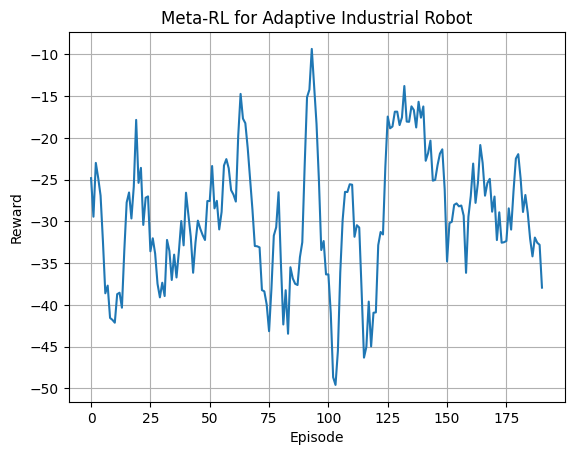

Final Average Reward: -37.93


In [3]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Manufacturing Environment
class RobotEnv:
    def __init__(self):
        self.goal = 0

    def reset(self):
        self.goal = np.random.uniform(-1, 1)
        self.pos = np.random.uniform(-1, 1)
        return np.array([self.pos, self.goal], dtype=np.float32)

    def step(self, action):
        self.pos += [-0.1, 0, 0.1][action]
        reward = -abs(self.pos - self.goal)
        done = abs(self.pos - self.goal) < 0.1
        return np.array([self.pos, self.goal], dtype=np.float32), reward, done


# Meta-RL Policy
class MetaPolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Softmax(-1)
        )

    def forward(self, x):
        return self.net(x)


env = RobotEnv()
model = MetaPolicy()
optimizer = optim.Adam(model.parameters(), lr=0.001)

rewards = []

# Meta Training
for episode in range(200):

    state = env.reset()
    loss = 0
    total = 0

    for step in range(50):

        s = torch.tensor(state).float()
        dist = torch.distributions.Categorical(model(s))

        action = dist.sample()

        state, reward, done = env.step(action.item())

        loss += -dist.log_prob(action) * reward
        total += reward

        if done:
            break

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    rewards.append(total)

# Result
plt.plot(np.convolve(rewards, np.ones(10)/10, mode="valid"))
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Meta-RL for Adaptive Industrial Robot")
plt.grid()
plt.show()

print("Final Average Reward:",
      round(np.mean(rewards[-10:]), 2))

19

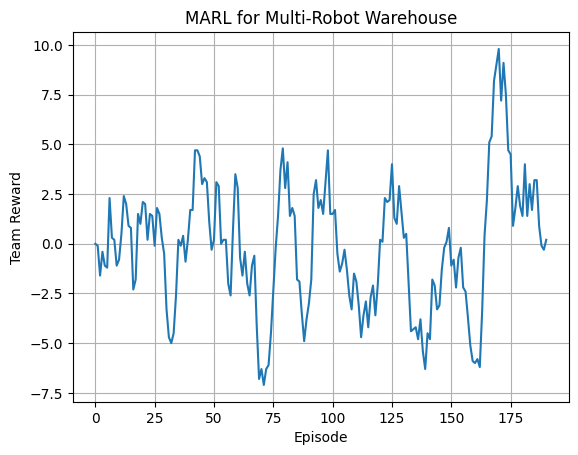

Final Average Team Reward: 0.2


In [4]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Warehouse
robots = 3
tasks = 3

# Policy Network
class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, tasks),
            nn.Softmax(-1)
        )

    def forward(self, x):
        return self.net(x)

agents = [Agent() for _ in range(robots)]
opts = [optim.Adam(a.parameters(), lr=.001) for a in agents]

rewards = []

# MARL Training
for episode in range(200):

    positions = np.random.randint(0, 10, robots)
    goals = np.random.randint(0, 10, tasks)
    total = 0

    for i, agent in enumerate(agents):

        state = torch.tensor([
            positions[i], goals[0],
            goals[1], goals[2]
        ]).float()

        dist = torch.distributions.Categorical(
            agent(state)
        )

        action = dist.sample()

        target = goals[action.item()]
        reward = -abs(
            positions[i] - target
        )

        # Cooperation bonus
        if abs(positions[i] - target) < 2:
            reward += 10

        loss = -dist.log_prob(action) * reward

        opts[i].zero_grad()
        loss.backward()
        opts[i].step()

        total += reward

    rewards.append(total)

# Result
plt.plot(
    np.convolve(
        rewards,
        np.ones(10)/10,
        mode="valid"
    )
)

plt.xlabel("Episode")
plt.ylabel("Team Reward")
plt.title("MARL for Multi-Robot Warehouse")
plt.grid()
plt.show()

print(
    "Final Average Team Reward:",
    round(np.mean(rewards[-10:]), 2)
)

20

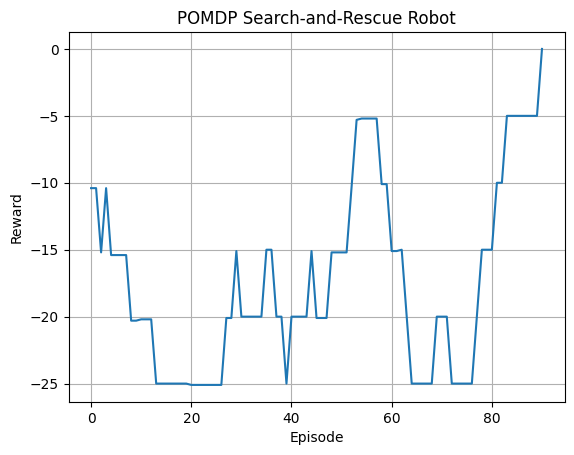

Average Reward: 0.0


In [5]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt

# POMDP Search-and-Rescue
rooms = 5
belief = np.ones(rooms) / rooms
robot = 0
rewards = []

for episode in range(100):

    victim = np.random.randint(rooms)
    robot = 0
    belief = np.ones(rooms) / rooms
    total = 0

    for step in range(30):

        # Choose room with highest belief
        action = np.argmax(belief)
        robot = action

        # Partial observation
        found = (robot == victim and np.random.rand() > 0.2)

        if found:
            reward = 20
            total += reward
            break
        else:
            reward = -1
            total += reward

            # Update belief
            belief *= 0.8
            belief[robot] += 0.2
            belief /= belief.sum()

    rewards.append(total)

# Performance
plt.plot(
    np.convolve(
        rewards,
        np.ones(10) / 10,
        mode="valid"
    )
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("POMDP Search-and-Rescue Robot")
plt.grid()
plt.show()

print(
    "Average Reward:",
    round(np.mean(rewards[-10:]), 2)
)